# Testes não paramétricos

## Testes para duas amostras emparelhadas

Esses testes investigam se duas amostras estão, de alguma forma, relacionadas entre si. Os exemplos mais comuns analisam uma situação antes e depois de um acontecimento.

### Teste de Wilcoxon

O teste de Wilcoxon é uma alternativa ao teste t quando a distribuição dos dados não for aderente à distribuição normal.

A hipótese nula assume que a mediana das diferenças na população $M_d$ seja zero, ou seja, as populações não diferem em localização. Para um teste bilateral, temos que:

$$
\begin{align}
H_0: M_d = 0 \\
H_1: M_d \neq 0
\end{align}
$$

Em outras palavras, devemos testar a hipótese de que não há diferenças entre as duas amostras (as amostras são provenientes de populações com a mesma mediana e a mesma distribuição contínua).

Exemplo: Um grupo de 18 alunos de ensino médio de um colégio é submetido a um exame de proficiência na língua inglesa, sem nunca ter feito um curso extracurricular. O mesmo grupo de alunos é submetido a um curso intensivo de inglês por 6 meses e, ao final, fazem novamente o exame de proficiência. Os resultados são apresentados na base a seguir. Teste a hipótese de que não ocorrem melhoras antes e depois do curso. Considere $\alpha = 5\%$.

In [1]:
import pandas as pd

BASE_INGLES = "./dados/english.csv"

df_ingles = pd.read_csv(BASE_INGLES)

df_ingles

,Before,After
0,56,60
1,65,62
2,70,74
3,78,79
4,47,53
5,52,59
6,64,65
7,70,75
8,72,75
9,78,88


In [2]:
df_ingles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Before  18 non-null     int64
 1   After   18 non-null     int64
dtypes: int64(2)
memory usage: 420.0 bytes


In [3]:
df_ingles.describe()

,Before,After
count,18.000000,18.000000
mean,60.388889,64.277778
std,16.918973,16.792174
min,17.000000,24.000000
25%,55.250000,59.250000
50%,64.500000,68.000000
75%,70.750000,75.000000
max,80.000000,88.000000


<Axes: ylabel='Count'>

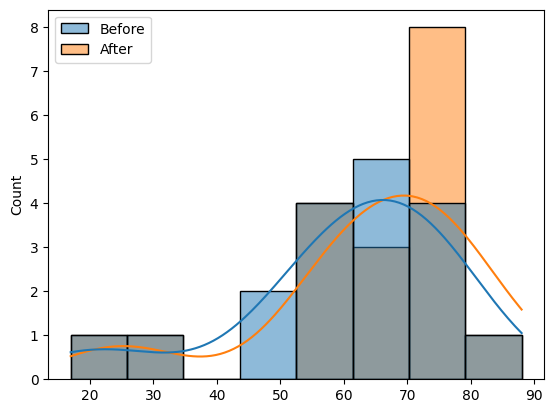

In [4]:
import seaborn as sns

sns.histplot(df_ingles,kde=True)

<Axes: >

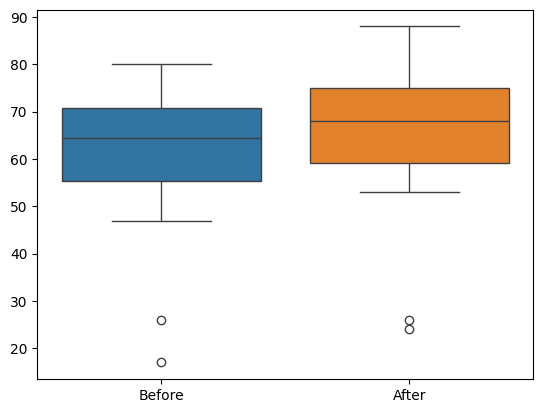

In [5]:
sns.boxplot(data=df_ingles)

In [6]:
from auxiliares import analises_shapiro_levene

analises_shapiro_levene(df_ingles,center="median")

teste de shapiro
 estatistica_sw =0.869
Before não segue uma distribuição normal (valor p: 0.017)
 estatistica_sw =0.854
After não segue uma distribuição normal (valor p: 0.010)

teste de levene
estatistica_levene =0.001
Variancia Iguais (valor p: 0.978)


https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html

In [7]:
from scipy.stats import wilcoxon

wilcoxon(df_ingles["Before"], df_ingles['After'])

WilcoxonResult(statistic=np.float64(11.5), pvalue=np.float64(0.0034449049423722184))

In [8]:
from auxiliares import analise_wilcoxon

analise_wilcoxon(df_ingles)

teste de Wilcoxon
estatistica_wilcoxon =11.500
Rejeita a hipótese nula (valor p: 0.003)
